MAE: 31155.7466210995
R2 Score: 0.6493897267876736
✅ Predictions saved!


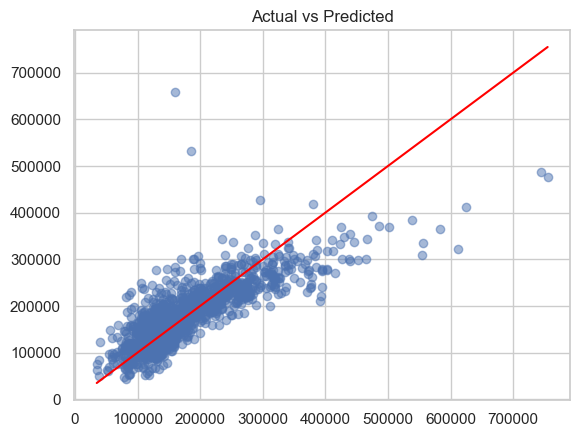

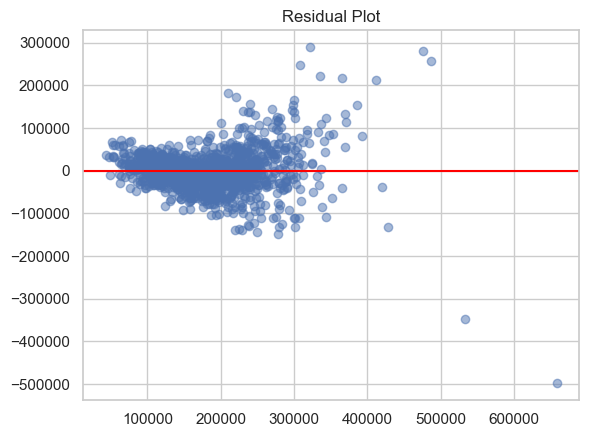

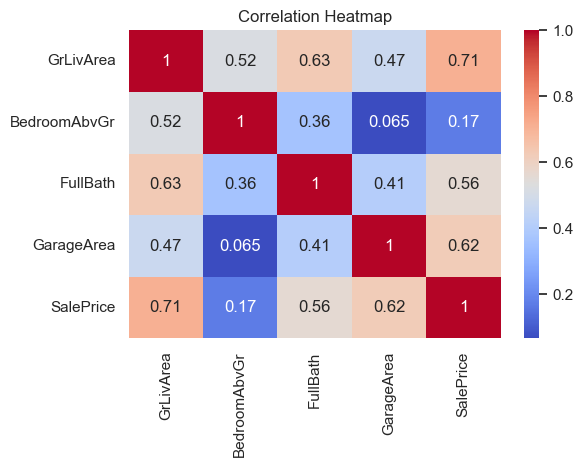

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Load data
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

# Clean column names
train_data.columns = train_data.columns.str.strip()
test_data.columns = test_data.columns.str.strip()

# Features
FEATURES = ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'GarageArea']
TARGET = 'SalePrice'

# Fill missing values (IMPORTANT FIX)
train_data[FEATURES] = train_data[FEATURES].fillna(train_data[FEATURES].mean())
test_data[FEATURES] = test_data[FEATURES].fillna(test_data[FEATURES].mean())

# Train data
X_train = train_data[FEATURES]
y_train = train_data[TARGET]

# Test data
X_test = test_data[FEATURES]

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_train, train_pred))
print("R2 Score:", r2_score(y_train, train_pred))

# Save predictions
output = pd.DataFrame({
    'Id': test_data['Id'],
    'PredictedPrice': test_pred
})

output.to_csv("predictions.csv", index=False)
print("✅ Predictions saved!")

# ------------------ GRAPHS ------------------

sns.set(style="whitegrid")

# Actual vs Predicted
plt.scatter(y_train, train_pred, alpha=0.5)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         color='red')
plt.title("Actual vs Predicted")
plt.show()

# Residual plot
residuals = y_train - train_pred
plt.scatter(train_pred, residuals, alpha=0.5)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.show()

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(train_data[FEATURES + [TARGET]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()